# Домашнее задание - линейная регрессия

### Работа с признаками (8 баллов)

Скачайте датасет из материалов к уроку или по ссылке https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv


Описание признаков:

* Agency — название страхового агентства
* Agency Type — тип страхового агентства
* Distribution Channel — канал продвижения страхового агентства
* Product Name — название страхового продукта
* Duration — длительность поездки (количество дней)
* Destination — направление поездки
* Net Sales — сумма продаж
* Commission (in value) — комиссия страхового агентства
* Gender — пол застрахованного
* Age — возраст застрахованного

Ответ:
* Claim — потребовалась ли страховая выплата: «да» — 1, «нет» — 0

Обработайте пропущенные значения и примените написанные функции onehot_encode() и minmax_scale().

**Подсказка**: маску для категориальных признаков можно сделать фильтром cat_features_mask = (df.dtypes == "object").values

In [ ]:
import pandas as pd
import numpy as np

url = 'https://raw.githubusercontent.com/jupiterzhuo/travel-insurance/master/travel%20insurance.csv'
df = pd.read_csv(url)
df.info()
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63326 entries, 0 to 63325
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                63326 non-null  object 
 1   Agency Type           63326 non-null  object 
 2   Distribution Channel  63326 non-null  object 
 3   Product Name          63326 non-null  object 
 4   Claim                 63326 non-null  object 
 5   Duration              63326 non-null  int64  
 6   Destination           63326 non-null  object 
 7   Net Sales             63326 non-null  float64
 8   Commision (in value)  63326 non-null  float64
 9   Gender                18219 non-null  object 
 10  Age                   63326 non-null  int64  
dtypes: float64(2), int64(2), object(7)
memory usage: 5.3+ MB
Agency                      0
Agency Type                 0
Distribution Channel        0
Product Name                0
Claim                       0
Duration        

In [ ]:
# Проанализируем пропуски. Повезло, они есть только в одном столбце.
# В столбце gender пропусков больше половины, как-либо заполнять их не имеет смысла.
df = df.drop(['Gender'], axis=1)

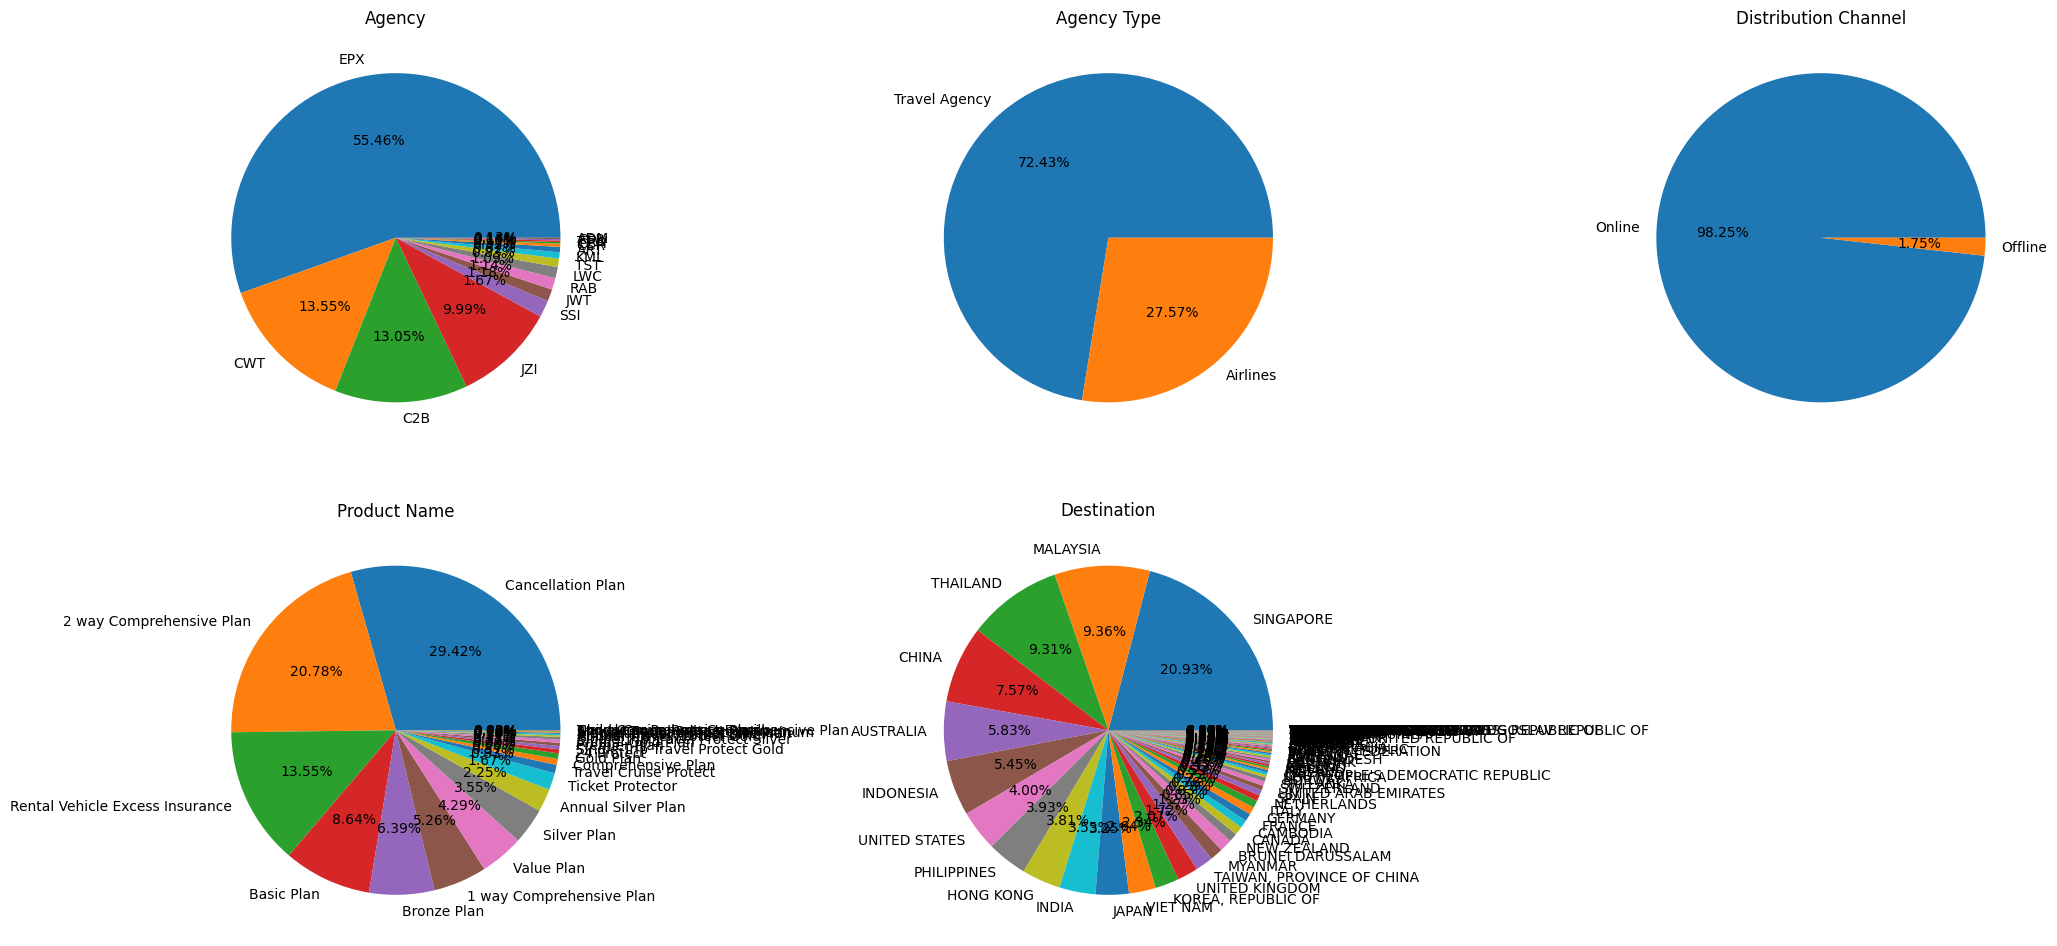

In [ ]:
# Проанализируем и сгруппируем редкие категорий

import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plt.subplot(231); plt.pie(df['Agency'].value_counts(), labels=df['Agency'].value_counts().index, autopct='%1.2f%%'); plt.title('Agency')
plt.subplot(232); plt.pie(df['Agency Type'].value_counts(), labels=df['Agency Type'].value_counts().index, autopct='%1.2f%%'); plt.title('Agency Type')
plt.subplot(233); plt.pie(df['Distribution Channel'].value_counts(), labels=df['Distribution Channel'].value_counts().index, autopct='%1.2f%%'); plt.title('Distribution Channel')
plt.subplot(234); plt.pie(df['Product Name'].value_counts(), labels=df['Product Name'].value_counts().index, autopct='%1.2f%%'); plt.title('Product Name')
plt.subplot(235); plt.pie(df['Destination'].value_counts(), labels=df['Destination'].value_counts().index, autopct='%1.2f%%'); plt.title('Destination')

plt.tight_layout()
plt.show()

'''
У 'Agency Type' и 'Distribution Channel' есть дисбаланс классов.
У 'Distribution Channel' большой дисбаланс, поэтому просто избавимся от него.
Для 'Agency' объединим в 'Other' категории < 9.99 %.
Для 'Product Name' объединим в 'Other' категории < 5.26 %.
Для 'Destination' объединим в 'Other' категории < 3.5 %.
'''
df = df.drop(columns=["Distribution Channel"])

agency_share = df['Agency'].value_counts(normalize=True)
agency_rare = agency_share[agency_share < 0.0999].index
df['Agency'] = df['Agency'].replace(agency_rare, 'Other')

product_share = df['Product Name'].value_counts(normalize=True)
product_rare = product_share[product_share < 0.0526].index
df['Product Name'] = df['Product Name'].replace(product_rare, 'Other')

destination_share = df['Destination'].value_counts(normalize=True)
destination_rare = destination_share[destination_share < 0.035].index
df['Destination'] = df['Destination'].replace(destination_rare, 'Other')

Столбец 'Agency': 12 редких категорий объединены в 'Other'.
Столбец 'Product Name': 20 редких категорий объединены в 'Other'.
Столбец 'Destination': 139 редких категорий объединены в 'Other'.


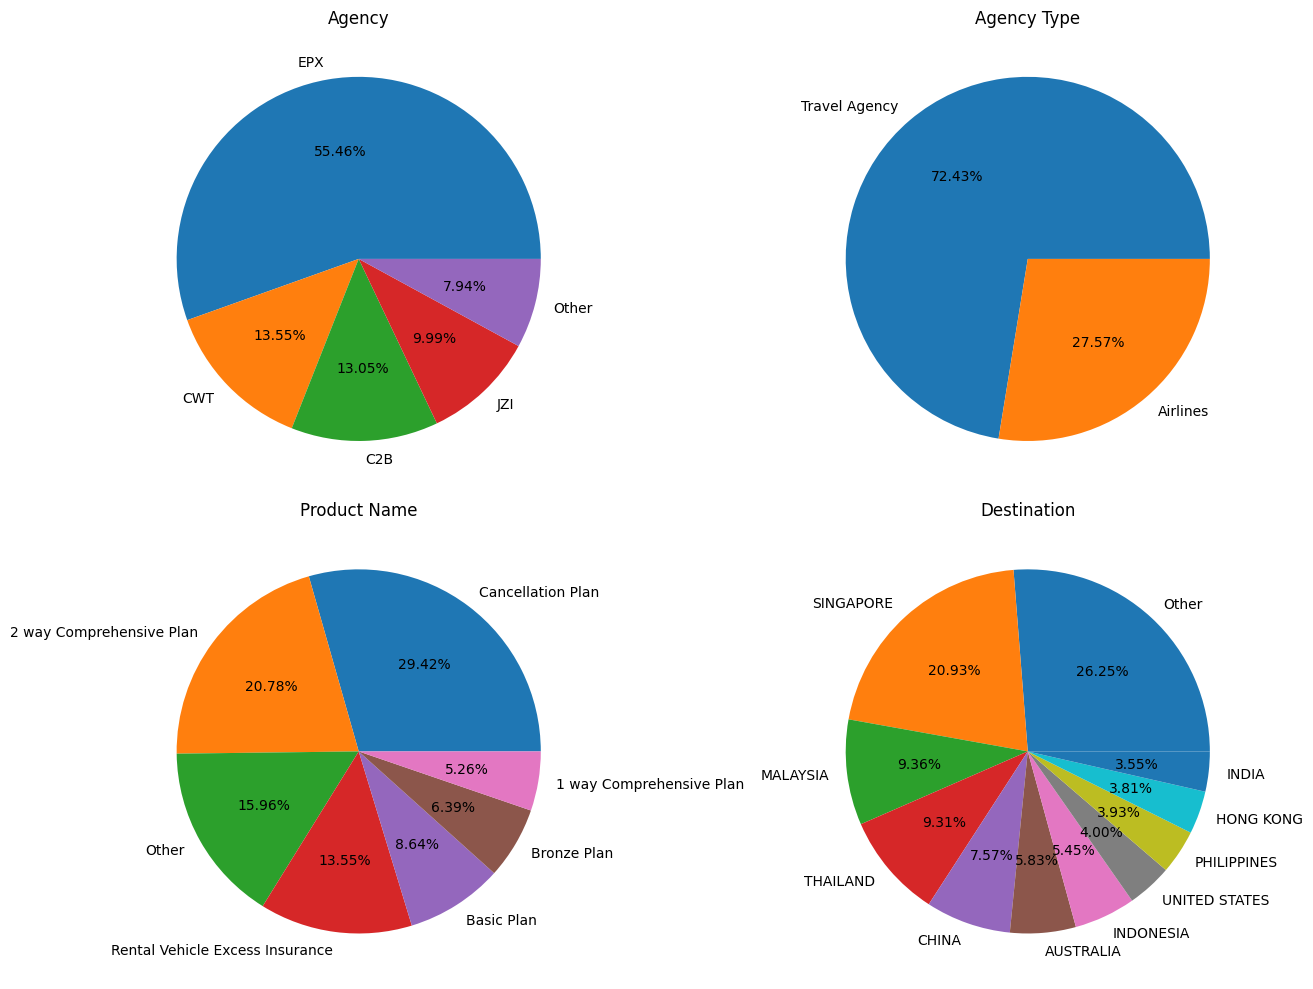

In [ ]:
plt.figure(figsize=(20,10))

print(f"Столбец 'Agency': {len(agency_rare)} редких категорий объединены в 'Other'.")
print(f"Столбец 'Product Name': {len(product_rare)} редких категорий объединены в 'Other'.")
print(f"Столбец 'Destination': {len(destination_rare)} редких категорий объединены в 'Other'.")

plt.subplot(231); plt.pie(df['Agency'].value_counts(), labels=df['Agency'].value_counts().index, autopct='%1.2f%%'); plt.title('Agency')
plt.subplot(232); plt.pie(df['Agency Type'].value_counts(), labels=df['Agency Type'].value_counts().index, autopct='%1.2f%%'); plt.title('Agency Type')
plt.subplot(234); plt.pie(df['Product Name'].value_counts(), labels=df['Product Name'].value_counts().index, autopct='%1.2f%%'); plt.title('Product Name')
plt.subplot(235); plt.pie(df['Destination'].value_counts(), labels=df['Destination'].value_counts().index, autopct='%1.2f%%'); plt.title('Destination')

plt.tight_layout()
plt.show()

Анализ признака duration

Статистика до обработки:
count    63326.000000
mean        49.317074
std        101.791566
min         -2.000000
25%          9.000000
50%         22.000000
75%         53.000000
max       4881.000000
Name: Duration, dtype: float64

Границы для определения выбросов:
Q1 (25-й перцентиль): 9.00
Q3 (75-й перцентиль): 53.00
IQR (межквартильный размах): 44.00
Нижняя граница: -57.00
Верхняя граница: 119.00

Результаты обработки:
Исходное количество строк: 63326
После удаления выбросов: 57760
Удалено строк: 5566 (6332508.79%)

Статистика после обработки:
count    57760.000000
mean        29.055609
std         26.934954
min         -2.000000
25%          9.000000
50%         19.000000
75%         41.000000
max        119.000000
Name: Duration, dtype: float64

Удалено 5566 записей с экстремальными значениями Duration
Максимальное значение уменьшилось с 4881 до 119
Среднее значение изменилось с 49.32 до 29.06


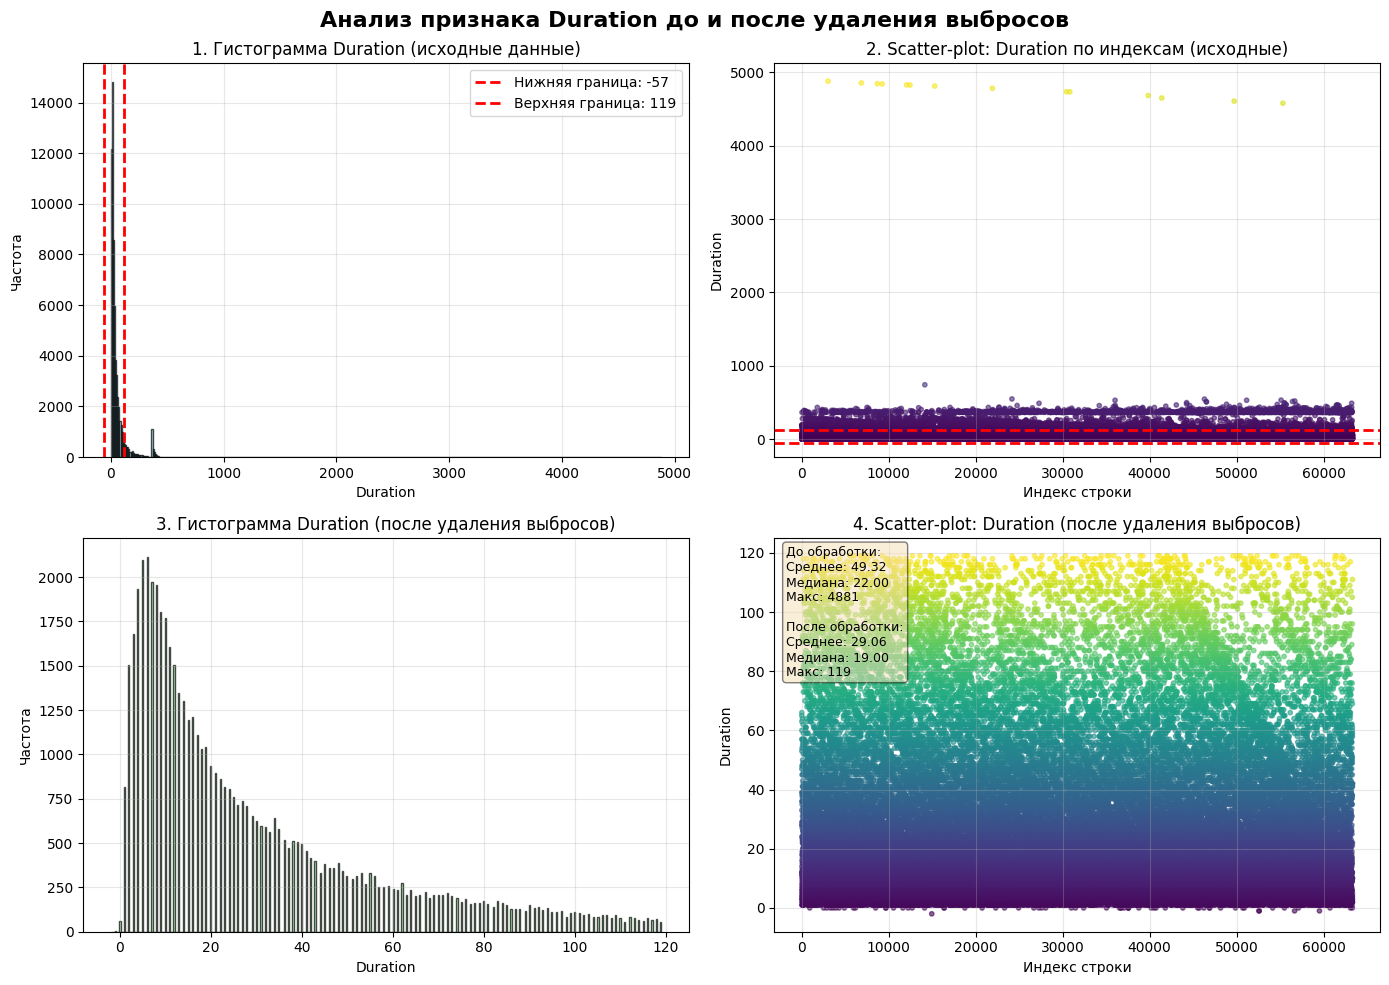

In [ ]:
import matplotlib.pyplot as plt

print("Анализ признака duration")

print("\nСтатистика до обработки:")
print(df['Duration'].describe())

# Определим границы для выбросов методом межквартильного размаха (IQR)
Q1 = df['Duration'].quantile(0.25)
Q3 = df['Duration'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"\nГраницы для определения выбросов:")
print(f"Q1 (25-й перцентиль): {Q1:.2f}")
print(f"Q3 (75-й перцентиль): {Q3:.2f}")
print(f"IQR (межквартильный размах): {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")

# Сохраним исходные данные для визуализации
df_before = df.copy()
initial_rows = len(df)

# Удалим выбросы
df = df[
    (df['Duration'] >= lower_bound) &
    (df['Duration'] <= upper_bound)
].copy()

# Статистика после удаления
print(f"\nРезультаты обработки:")
print(f"Исходное количество строк: {initial_rows}")
print(f"После удаления выбросов: {len(df)}")
print(f"Удалено строк: {initial_rows - len(df)} ({(initial_rows - len(df) / initial_rows) * 100:.2f}%)")

print("\nСтатистика после обработки:")
print(df['Duration'].describe())

# Визуализация результатов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Анализ признака Duration до и после удаления выбросов', fontsize=16, fontweight='bold')

# График 1: Гистограмма исходных данных
axes[0, 0].hist(df_before['Duration'], bins=500, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('1. Гистограмма Duration (исходные данные)', fontsize=12)
axes[0, 0].set_xlabel('Duration', fontsize=10)
axes[0, 0].set_ylabel('Частота', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
# Добавим вертикальные линии для границ
axes[0, 0].axvline(lower_bound, color='red', linestyle='--', linewidth=2, label=f'Нижняя граница: {lower_bound:.0f}')
axes[0, 0].axvline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'Верхняя граница: {upper_bound:.0f}')
axes[0, 0].legend()

# График 2: Scatter-plot исходных данных
axes[0, 1].scatter(df_before.index, df_before['Duration'],
                   c=df_before['Duration'], cmap='viridis', s=10, alpha=0.6)
axes[0, 1].set_title('2. Scatter‑plot: Duration по индексам (исходные)', fontsize=12)
axes[0, 1].set_xlabel('Индекс строки', fontsize=10)
axes[0, 1].set_ylabel('Duration', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axhline(lower_bound, color='red', linestyle='--', linewidth=2)
axes[0, 1].axhline(upper_bound, color='red', linestyle='--', linewidth=2)

# График 3: Гистограмма после удаления выбросов
axes[1, 0].hist(df['Duration'], bins=500, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('3. Гистограмма Duration (после удаления выбросов)', fontsize=12)
axes[1, 0].set_xlabel('Duration', fontsize=10)
axes[1, 0].set_ylabel('Частота', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)

# График 4: Scatter-plot после удаления выбросов
axes[1, 1].scatter(df.index, df['Duration'],
                   c=df['Duration'], cmap='viridis', s=10, alpha=0.6)
axes[1, 1].set_title('4. Scatter‑plot: Duration (после удаления выбросов)', fontsize=12)
axes[1, 1].set_xlabel('Индекс строки', fontsize=10)
axes[1, 1].set_ylabel('Duration', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# Добавим информационную панель с ключевыми статистиками
stats_text = f"До обработки:\nСреднее: {df_before['Duration'].mean():.2f}\nМедиана: {df_before['Duration'].median():.2f}\nМакс: {df_before['Duration'].max():.0f}"
stats_text += f"\n\nПосле обработки:\nСреднее: {df['Duration'].mean():.2f}\nМедиана: {df['Duration'].median():.2f}\nМакс: {df['Duration'].max():.0f}"
axes[1, 1].text(0.02, 0.98, stats_text, transform=axes[1, 1].transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

print(f"\nУдалено {initial_rows - len(df)} записей с экстремальными значениями Duration")
print(f"Максимальное значение уменьшилось с {df_before['Duration'].max():.0f} до {df['Duration'].max():.0f}")
print(f"Среднее значение изменилось с {df_before['Duration'].mean():.2f} до {df['Duration'].mean():.2f}")

plt.tight_layout()
plt.show()

In [ ]:
def onehot_encoding(arr): # это моя функция старая
    amount = len(arr)
    values = sorted(set(arr))
    a = np.zeros((amount, len(values)), dtype=int)
    for i in range(amount):
        a[i][values.index(arr[i])] = 1
    return a

'''
В аналитическом решении оказалось, что матрица вырожденная. Onehot_encoding создает линейную зависимость.
Я исправила функцию, чтобы она возвращала матрицу с len(values) - 1 столбцами.
Это называется "drop first" или "dummy encoding".
Удаленный столбец становится "базовым" (reference category). Его эффект поглощается свободным членом (bias).

Без удаления столбца:

X = [Красный, Синий, Зеленый]
Вес_Красный + Вес_Синий + Вес_Зеленый = 0  # линейная зависимость!
Матрица вырожденная, значит нет решения

С удалением столбца:

X = [Красный, Синий]  # Зеленый — базовый
Предсказание = bias + Вес_Красный*Красный + Вес_Синий*Синий

Если объект Зеленый: предсказание = bias
Если объект Красный: предсказание = bias + Вес_Красный
Разница между Красным и Зеленым = Вес_Красный
'''
def onehot_encoding_drop_first(arr): # делаем новую функцию, чтобы избавиться от той линейной зависимости
    amount = len(arr)
    values = sorted(set(arr))
    # Удаляем первую категорию из списка
    encoded_values = values[1:]  # Все категории кроме первой
    a = np.zeros((amount, len(encoded_values)), dtype=int)
    for i in range(amount):
        if arr[i] in encoded_values:
            idx = encoded_values.index(arr[i])
            a[i][idx] = 1
    return a


def minmax_scale(matrix):
    matrix = np.array(matrix, dtype=float)
    n, m = matrix.shape

    for i in range(m):
        column = matrix[:, i]
        minn = np.min(column)
        maxx = np.max(column)

        if maxx == minn:
            matrix[:, i] = 0.0
        else:
            matrix[:, i] = (column - minn) / (maxx - minn)

    return matrix

arrays = []
cat_features_mask = (df.dtypes == "object").values

for i in df.columns[cat_features_mask]:  # проходим по категориальным столбцам
    # arrays.append(onehot_encoding(df[i].values))
    arrays.append(onehot_encoding_drop_first(df[i].values))

X_cat = np.hstack(arrays)

# кроме Claim
num_features = [i for i in df.columns if df[i].dtype in ['int64', 'float64'] and i != 'Claim']
X_num = df[num_features].values  # преобразование в массив NumPy
X_num = minmax_scale(X_num)


X = np.hstack([X_num, X_cat])
# X = np.hstack([X_num])
y = df['Claim'].values

print(X.shape)
print(y.shape) # вектор

(57760, 26)
(57760,)


In [ ]:
from sklearn.utils import resample

# Борьба с дисбалансом классов (downsampling)

# Проверим распределение классов до балансировки
unique, counts = np.unique(y, return_counts=True)
class_distribution = dict(zip(unique, counts))
print(f"\nРаспределение классов до балансировки:")
for cls, cnt in class_distribution.items():
    percentage = (cnt / len(y)) * 100
    print(f"   Класс {cls}: {cnt} записей ({percentage:.2f}%)")

# Находим индексы каждого класса
indices_class_0 = np.where(y == 'No')[0]
indices_class_1 = np.where(y == 'Yes')[0]

# Определяем размер меньшего класса
n_samples = min(len(indices_class_0), len(indices_class_1))
print(f"\nРазмер меньшего класса: {n_samples}")

# Делаем downsample для большего класса
if len(indices_class_0) > len(indices_class_1):
    # Класс 0 больше - делаем downsample для него
    print("Выполняется downsampling для класса No")
    indices_class_0_downsampled = resample(indices_class_0,
                                            replace=False,
                                            n_samples=n_samples,
                                            random_state=42)
    indices_class_1_downsampled = indices_class_1
else:
    # Класс 1 больше - делаем downsample для него
    print("Выполняется downsampling для класса Yes")
    indices_class_1_downsampled = resample(indices_class_1,
                                            replace=False,
                                            n_samples=n_samples,
                                            random_state=42)
    indices_class_0_downsampled = indices_class_0

# Объединяем индексы
downsampled_indices = np.concatenate([indices_class_0_downsampled,
                                      indices_class_1_downsampled])

# Создаем новые сбалансированные X и y
X = X[downsampled_indices]
y = y[downsampled_indices]
y = np.where(y == 'Yes', 1, 0)

# Проверяем распределение после балансировки
unique_after, counts_after = np.unique(y, return_counts=True)
print(f"\nРаспределение классов после балансировки:")
for cls, cnt in zip(unique_after, counts_after):
    percentage = (cnt / len(y)) * 100
    print(f"   Класс {cls}: {cnt} записей ({percentage:.2f}%)")
print(f"\nНовый размер данных: {X.shape}")


Распределение классов до балансировки:
   Класс No: 57066 записей (98.80%)
   Класс Yes: 694 записей (1.20%)

Размер меньшего класса: 694
Выполняется downsampling для класса No

Распределение классов после балансировки:
   Класс 0: 694 записей (50.00%)
   Класс 1: 694 записей (50.00%)

Новый размер данных: (1388, 26)


Подробный анализ и подготовка датасета часто помогают улучшить качество модели. Ниже представлено несколько идей преобразований. Вы можете применить одно или несколько из этих преобразований (а можете не применять), чтобы помочь будущей модели.

1. Посмотрите на количественные признаки. Возможно, в некоторых признаках есть выбросы - значения, которые сильно выбиваются. Такие значения полезно удалять. Советуем присмотреться к колонке Duration)

2. Можно заметить, что one hot encoding сильно раздувает количество столбцов. Радикальное решение - можно попробовать выбросить все категориальные признаки из датасета.

3. Если все-таки оставляете категориальные признаки, то подумайте, как уменьшить количество столбцов после one hot encoding. Признаки с большим количеством значений (Duration - 149! разных стран) можно удалить или попробовать сгруппировать некоторые значения.

4. Downsampling. Датасет достаточно большой, разница в классах огромная. Можно уменьшить число наблюдений с частым ответом.

### Применение линейной регрессии (10 баллов)

Это задача классификации, но её можно решить с помощью линейной регрессии, если округлять предсказанный ответ до целого и выбирать ближайший по значению ответ из множества {0, 1}.

Вынесите признак 'Claim' в вектор ответов и разделите датасет на обучающую и тестовую выборку в соотношении 80 к 20. Зафиксируйте random_state.

**Подсказка:** быстро перевести Yes/No в 1/0 можно так - np.where(df['Claim'] == 'Yes', 1,0)

In [ ]:
from sklearn.model_selection import train_test_split

# Разделение на train/test (с сохранением пропорций классов)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    train_size=0.8,
    random_state=42,
    stratify=y  # stratify сохранит пропорции классов
)

print(f"Обучающая выборка: {X_train.shape[0]} записей")
print(f"Тестовая выборка: {X_test.shape[0]} записей")

# Проверка распределения в train/test
print("\nРаспределение в обучающей выборке:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique_train, counts_train):
    percentage = (cnt / len(y_train)) * 100
    print(f"Класс {cls}: {cnt} записей ({percentage:.2f}%)")

print("\nРаспределение в тестовой выборке:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for cls, cnt in zip(unique_test, counts_test):
    percentage = (cnt / len(y_test)) * 100
    print(f"Класс {cls}: {cnt} записей ({percentage:.2f}%)")

Обучающая выборка: 1110 записей
Тестовая выборка: 278 записей

Распределение в обучающей выборке:
Класс 0: 555 записей (50.00%)
Класс 1: 555 записей (50.00%)

Распределение в тестовой выборке:
Класс 0: 139 записей (50.00%)
Класс 1: 139 записей (50.00%)


Найдите аналитическое решение для обучающей выборки: обычное и регуляризацией l2.

In [ ]:
# посчитайте аналитическое решение

from sklearn.metrics import mean_squared_error

# + столбец единиц (это bias)
X_train_with_bias = np.column_stack([np.ones(X_train.shape[0]), X_train])
X_test_with_bias = np.column_stack([np.ones(X_test.shape[0]), X_test])

w = np.linalg.inv(X_train_with_bias.T @ X_train_with_bias) @ X_train_with_bias.T @ y_train
print("Веса:", w)

y_pred = X_test_with_bias @ w
y_pred_binary = (y_pred > 0.5).astype(int)
mse = mean_squared_error(y_test, y_pred_binary)
print(f"\nMSE для аналитического решения: {mse:.15f}")

Веса: [-6.28502852e+00  2.45256109e-01  1.14717060e+01 -1.25934969e+01
  1.03029233e+00  4.45825872e+01  2.32642137e+00 -3.81148726e-01
 -1.17548111e-01 -4.16451486e-03  2.47138403e-03  2.51665061e+00
  2.60862375e+00 -2.11972367e-15  2.54528831e+00 -3.05220882e+01
  1.00000000e+00  5.23886490e-16  2.36269337e-15  3.26128013e-16
 -3.85108612e-16  6.72378819e-15  7.83054177e-15  2.22044605e-15
  3.66026653e-15 -3.31679129e-15 -1.66255898e-14]

MSE для аналитического решения: 0.428057553956835


In [ ]:
# посчитать аналитическое решение с регуляризацией

from sklearn.metrics import mean_squared_error

for lambda_l2 in [1.0, 100.0, 1000.0]:
  n_features = X_train_with_bias.shape[1]
  I = lambda_l2 * np.eye(n_features)

  w_r = np.linalg.inv(X_train_with_bias.T @ X_train_with_bias + I) @ X_train_with_bias.T @ y_train
  print("\nВеса:", w_r)

  y_pred = X_test_with_bias @ w_r
  mse = mean_squared_error(y_test, y_pred)
  print(f"\nMSE для аналитического решения с регуляризацией (лямбда {lambda_l2}): {mse:.40f}")


Веса: [ 1.57708484e-03  4.13837722e-04  1.97023956e-03  2.98816599e-03
 -1.26964996e-04 -8.79546159e-04 -2.51432701e-03 -2.13505467e-03
 -2.70796393e-03  1.16419948e-03  1.26117317e-03  9.70857060e-04
  2.06078301e-03 -2.05530599e-04  1.93931793e-03 -8.79546159e-04
  9.94961266e-01  4.37250416e-04  4.92742727e-04 -5.64146972e-04
 -1.65140401e-04 -5.18027476e-04 -1.04135337e-04 -5.32538932e-04
 -5.87626810e-04 -2.28537587e-04  2.92747175e-04]

MSE для аналитического решения с регуляризацией (лямбда 1.0): 0.0000045653090730052282324364677779104937

Веса: [ 0.07716259  0.02664393  0.04215503  0.01889099  0.01605212  0.00753582
 -0.02331026 -0.00778614 -0.01734105  0.0031454   0.03022359 -0.00772248
  0.05542742 -0.03655956  0.04523208  0.00753582  0.7046496   0.01536865
  0.00908875 -0.00884871  0.00149799 -0.00918362  0.0045765  -0.00375629
  0.0502555  -0.00127937  0.00770425]

MSE для аналитического решения с регуляризацией (лямбда 100.0): 0.0168410875995033439134207498000250780024

В

Постройте модель LinearRegression, примените к тестовой выборке и посчитайте MSE (можно использовать библиотеку sklearn)

In [ ]:
# обучите модель линейной регрессии LinearRegression на обучающей выборке, примените к тестовой

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(int)

In [ ]:
# посчитайте MSE, предварительно округлив предсказанные ответы до целого

from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse:.40f}")

MSE: 0.0000000000000000000000000000006189844500


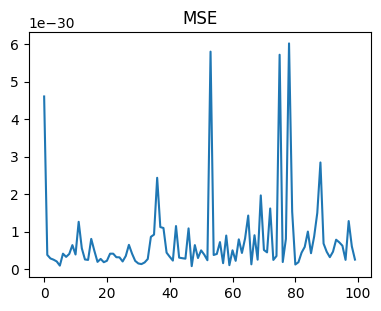

In [ ]:
mse = []

for i in range(100):
    X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, train_size=0.8)
    lin = LinearRegression()
    lin.fit(X_train2, y_train2)

    y_pred_lin = lin.predict(X_test2)
    mse.append(mean_squared_error(y_test2, y_pred_lin))


plt.figure(figsize=(15, 7))

plt.subplot(234)
plt.plot(np.arange(100), mse)
plt.title('MSE')

plt.show()

# ну вот если бы колебания были в районе 0.25, то было бы плохо, так как она бы не была особо лучше случайного угадывания,
# но у меня грфик примерно около 0.1, значит это хорошо. Но плохо, что есть вот эти скачки, в которых модель ломается.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Оценка модели с помощью разных метрик

accuracy = accuracy_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
f1 = f1_score(y_test, y_pred_binary)
roc_auc = roc_auc_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred_binary)

print(f"Accuracy (Доля правильных ответов): {accuracy:.4f}")
print(f"Precision (Точность): {precision:.4f}")
print(f"Recall (Полнота): {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nМатрица ошибок:")
print(cm)
tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

Accuracy (Доля правильных ответов): 1.0000
Precision (Точность): 1.0000
Recall (Полнота): 1.0000
F1-score: 1.0000
ROC-AUC: 1.0000

Матрица ошибок:
[[139   0]
 [  0 139]]
TN: 139
FP: 0
FN: 0
TP: 139


### Вывод (1 балла)

1. Удалила признак 'Gender', так как пропущено более 50% значений, заполнение их не имело бы смысла. В других столбцах пропусков нет.
2. В признаке 'Duration' были экстремальные значения, которые могли сильно влиять на модель. Удалила их с помощью метода межквартильного размаха (IQR).
3. Объединила редкие категории в 'Other', чтобы уменьшить количество фичей после one-hot encoding и избежать шума от плохо представленных классов. Использовала one-hot encoding с удалением первого уровня (drop-first). Это решило проблему мультиколлинеарности (линейной зависимости между признаками), из-за которой матрица была вырожденной и не получалось найти аналитическое решение.
4. Применила downsampling для класса '0' (Claim = No), чтобы сбалансировать обучающую выборку. Это должно помочь модели лучше выявлять редкие, но важные случаи страховых выплат ехе.
5. Все метрики капец идеальные, я не знаю, почему.Я думаю, что это следствие downsampling, которое решило проблему дисбаланса, но могло привести к потере части информации. Либо ошибки в коде, которые я не могу найти.